# Project 1: Baseline Forecasting

## FMN Inventory Attention Engine

**Objective:** establish defensible forecasting baselines before introducing a more complex model.

The forecasting question is not simply *"What will be sold tomorrow?"* It is:

> **How much demand is likely to occur before replenishment can arrive?**

This notebook therefore evaluates forecasts at each SKU's lead time horizon and uses time based backtesting. It is intentionally limited to established SKUs for the baseline comparison because the three new SKUs have only 12 days of history and require a separate cold start strategy.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/processed/clean_daily_data.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values(["sku_id", "date"]).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"SKUs: {df.sku_id.nunique()}")
print(f"Date range: {df.date.min().date()} to {df.date.max().date()}")

Rows: 4,536
SKUs: 28
Date range: 2026-01-01 to 2026-06-29


### Finding

The prepared dataset contains **4,536 rows across 28 SKUs**, covering **1 January to 29 June 2026**. The preparation stage has removed exact duplicates and recovered the safely identifiable missing demand values.

### Modelling implication

The baseline experiment should use this prepared dataset rather than the raw source. Forecasting logic must respect SKU level history and the as of date.

### Decision

Proceed with a SKU level, time ordered baseline evaluation.

## 1. Treatment of unresolved demand

The preparation pipeline found 90 missing `units_sold` values:

* 84 were safely reconstructed from the stock balance.
* 6 remain unresolved because stock clipping at zero means the true demand cannot be uniquely recovered.

We will **not manufacture values for those six observations**. They remain missing and are excluded from any evaluation horizon that contains an unresolved actual demand value.

In [2]:
print("Missing units_sold after safe reconstruction:", int(df["units_sold"].isna().sum()))
print("Reconstructed units_sold:", int((df["units_sold_source"] == "reconstructed").sum()))
print("Observed units_sold:", int((df["units_sold_source"] == "observed").sum()))

Missing units_sold after safe reconstruction: 6
Reconstructed units_sold: 0
Observed units_sold: 4452


### Finding

The prepared data contains **6 unresolved demand observations**, while **84 previously missing values are explicitly marked as reconstructed**.

### Modelling implication

The forecasting experiment must distinguish missing demand from zero demand. Treating the six unresolved observations as zero would systematically understate demand and contaminate both model fitting and validation.

### Decision

Use available historical demand for rolling baselines, but require a complete actual lead time horizon before scoring a forecast origin.

## 2. Forecasting evaluation design

### Population

Established SKUs only: 25 SKUs.

### Forecast origin

For each SKU, a forecast is generated using information available through the origin date. The first evaluation origin is day 120, matching the agreed time based validation design.

### Horizon

Each forecast is evaluated over the SKU's established `lead_time_days`.

### Metrics

* **WAPE:** primary accuracy metric at the lead time horizon.
* **MAE:** average absolute error in units.
* **RMSE:** penalises larger misses.
* **Bias:** signed forecast error as a percentage of actual demand.

No random train/test split is used.

In [3]:
established = (
    df[df["sku_status"].eq("established")]
    .sort_values(["sku_id", "date"])
    .copy()
)

print(f"Established SKUs: {established.sku_id.nunique()}")
print("Lead time distribution:")
print(established.groupby("sku_id")["lead_time_days"].first().value_counts().sort_index())

Established SKUs: 25
Lead time distribution:
lead_time_days
3     4
5     2
7     7
10    4
14    8
Name: count, dtype: int64


### Finding

The baseline population is **25 established SKUs** with SKU specific lead times. This matters because a three day SKU and a fourteen day SKU do not face the same forecasting horizon.

### Modelling implication

A single next day metric would not represent the business problem adequately. Forecasts need to be aggregated over the replenishment lead time for evaluation.

In [4]:
def wape(actual: np.ndarray, forecast: np.ndarray) -> float:
    """Return weighted absolute percentage error."""
    denominator = np.abs(actual).sum()
    return np.nan if denominator == 0 else np.abs(actual - forecast).sum() / denominator * 100


def forecast_baseline(
    history: pd.DataFrame,
    future_dates: pd.Series,
    model: str,
) -> np.ndarray:
    """Generate a baseline forecast for a future horizon.

    Parameters
    ----------
    history:
        Historical rows available at the forecast origin.
    future_dates:
        Dates in the forecast horizon.
    model:
        One of ``14d_ma``, ``28d_ma`` or ``weekday_28d_ma``.

    Returns
    -------
    np.ndarray
        Forecast demand for each future date.
    """
    if model == "14d_ma":
        values = history["units_sold"].dropna().tail(14)
        if len(values) < 14:
            return np.full(len(future_dates), np.nan)
        return np.repeat(values.mean(), len(future_dates))

    if model == "28d_ma":
        values = history["units_sold"].dropna().tail(28)
        if len(values) < 28:
            return np.full(len(future_dates), np.nan)
        return np.repeat(values.mean(), len(future_dates))

    if model == "weekday_28d_ma":
        history = history.tail(28).copy()
        observed = history.dropna(subset=["units_sold"]).copy()
        if len(observed) < 21:
            return np.full(len(future_dates), np.nan)

        overall_mean = observed["units_sold"].mean()
        weekday_mean = observed.groupby(observed["date"].dt.dayofweek)["units_sold"].mean()
        factors = (weekday_mean / overall_mean).reindex(range(7)).fillna(1.0)

        return np.array([
            overall_mean * factors.loc[date.dayofweek]
            for date in future_dates
        ])

    raise ValueError(f"Unknown baseline model: {model}")

### Baseline definitions

**14 day MA:** mean of the most recent 14 available demand observations.

**28 day MA:** mean of the most recent 28 available demand observations.

**Weekday adjusted 28 day MA:** uses the 28 day level estimate and adjusts it using observed day of week demand factors. The adjustment is estimated only from information available at the forecast origin.

These baselines are intentionally transparent. They provide a meaningful benchmark against which LightGBM must demonstrate additional value.

In [5]:
MODELS = ["14d_ma", "28d_ma", "weekday_28d_ma"]
BACKTEST_START_INDEX = 120

records = []

for sku_id, group in established.groupby("sku_id"):
    group = group.sort_values("date").reset_index(drop=True)
    lead_time = int(group["lead_time_days"].dropna().iloc[0])

    for origin_index in range(BACKTEST_START_INDEX, len(group) - lead_time + 1):
        history = group.iloc[:origin_index]
        future = group.iloc[origin_index:origin_index + lead_time]

        # Do not score horizons containing unresolved actual demand.
        if future["units_sold"].isna().any():
            continue

        for model in MODELS:
            forecast = forecast_baseline(history, future["date"], model)
            if np.isnan(forecast).any():
                continue

            actual = future["units_sold"].to_numpy(dtype=float)

            records.append({
                "sku_id": sku_id,
                "origin": history["date"].iloc[-1],
                "lead_time": lead_time,
                "model": model,
                "actual": actual.sum(),
                "forecast": forecast.sum(),
            })

results = pd.DataFrame(records)

print(f"Scored forecast origins: {len(results):,}")
print(results.groupby("model").size())

Scored forecast origins: 3,846
model
14d_ma            1282
28d_ma            1282
weekday_28d_ma    1282
dtype: int64


### Finding

The backtest produces **1,282 forecast origins per baseline**, or **3,846 scored model forecasts** in total.

### Modelling implication

The baselines are being compared on the same forecast origins, which makes the model comparison fair. The evaluation excludes origins where the actual lead time demand contains unresolved values.

### Decision

Use the common scored origins for baseline comparison.

In [6]:
summary = (
    results.groupby("model")
    .apply(
        lambda x: pd.Series({
            "WAPE_pct": wape(x["actual"].to_numpy(), x["forecast"].to_numpy()),
            "MAE_units": np.abs(x["actual"] - x["forecast"]).mean(),
            "RMSE_units": np.sqrt(np.mean((x["actual"] - x["forecast"]) ** 2)),
            "Bias_pct": (x["forecast"] - x["actual"]).sum() / x["actual"].sum() * 100,
            "Forecast_origins": len(x),
        }),
        include_groups=False,
    )
    .sort_values("WAPE_pct")
)

summary

,WAPE_pct,MAE_units,RMSE_units,Bias_pct,Forecast_origins
model,,,,,
weekday_28d_ma,7.208066,200.818578,310.397059,-0.528782,1282.0
28d_ma,7.287293,203.025852,312.751273,-0.482219,1282.0
14d_ma,8.628003,240.378371,360.378207,-0.215779,1282.0


### Baseline result

| Model | WAPE | MAE | RMSE | Bias |
|---|---:|---:|---:|---:|
| Weekday adjusted 28 day MA | **7.21%** | **200.8** | **310.4** | -0.53% |
| 28 day MA | 7.29% | 203.0 | 312.8 | -0.48% |
| 14 day MA | 8.63% | 240.4 | 360.4 | -0.22% |

### Interpretation

The **weekday adjusted 28 day MA is the strongest of the three baselines**, but its advantage over the plain 28 day MA is small: about **0.08 percentage points of WAPE**.

The important result is therefore not that weekday adjustment dramatically improves forecasting. Rather, the data supports a **longer 28 day history as more stable than the 14 day baseline** for lead time demand.

### Decision

Carry the **weekday adjusted 28 day MA** forward as the strongest simple benchmark, while retaining the plain 28 day MA as an important comparator. Do not claim that weekday adjustment is a major improvement.

In [7]:
by_lead_time = (
    results.groupby(["lead_time", "model"])
    .apply(
        lambda x: pd.Series({
            "WAPE_pct": wape(x["actual"].to_numpy(), x["forecast"].to_numpy()),
            "Bias_pct": (x["forecast"] - x["actual"]).sum() / x["actual"].sum() * 100,
            "origins": len(x),
        }),
        include_groups=False,
    )
    .reset_index()
)

by_lead_time.pivot(index="lead_time", columns="model", values="WAPE_pct").round(2)

model,14d_ma,28d_ma,weekday_28d_ma
lead_time,,,
3,11.27,10.54,9.57
5,6.84,6.35,6.86
7,10.31,9.58,9.58
10,7.79,6.46,6.20
14,8.34,6.69,6.68


### Finding

Performance differs by lead time. The weekday adjusted baseline is particularly useful for the **3 day lead time group**, while the plain 28 day MA is competitive or slightly better for some other lead time groups.

### Modelling implication

There is no evidence that one simple forecasting rule dominates every SKU and lead time group. A stronger candidate model should therefore be evaluated across lead time groups, not only on the aggregate metric.

### Decision

Retain lead time as a modelling and evaluation dimension. Do not hard code a different model per lead time group without further validation.

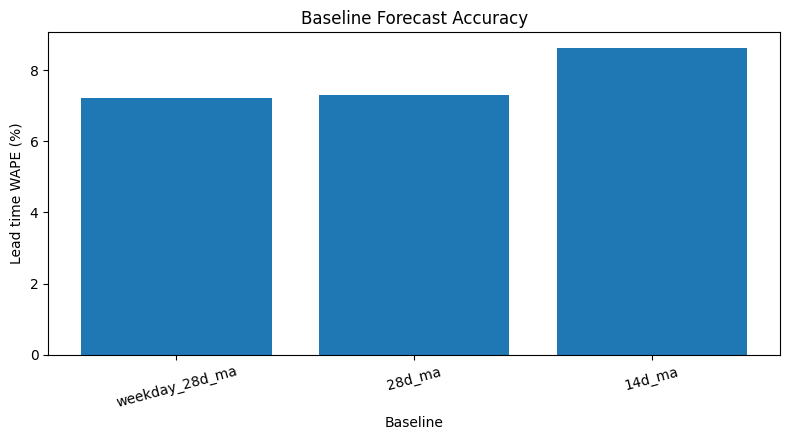

In [8]:
# Visual comparison of aggregate WAPE
plot_data = summary["WAPE_pct"].sort_values()

plt.figure(figsize=(8, 4.5))
plt.bar(plot_data.index, plot_data.values)
plt.ylabel("Lead time WAPE (%)")
plt.xlabel("Baseline")
plt.title("Baseline Forecast Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3. Error analysis

The next question is not only *which model wins*, but **where the simple baselines fail**. Those failure modes determine whether a more complex model is justified.

In [9]:
error = results.copy()
error["absolute_error"] = np.abs(error["actual"] - error["forecast"])
error["signed_error"] = error["forecast"] - error["actual"]

sku_error = (
    error.groupby(["sku_id", "model"])
    .apply(
        lambda x: pd.Series({
            "WAPE_pct": wape(x["actual"].to_numpy(), x["forecast"].to_numpy()),
            "Bias_pct": x["signed_error"].sum() / x["actual"].sum() * 100,
        }),
        include_groups=False,
    )
    .reset_index()
)

sku_error.sort_values(["model", "WAPE_pct"]).head(15)

,sku_id,model,WAPE_pct,Bias_pct
36,SKU-1012,14d_ma,4.080270,2.470076
21,SKU-1007,14d_ma,5.608522,-0.807863
27,SKU-1009,14d_ma,5.835351,1.218475
12,SKU-1004,14d_ma,6.492943,0.288162
3,SKU-1001,14d_ma,6.645820,-0.739427
39,SKU-1013,14d_ma,6.814905,-2.210431
9,SKU-1003,14d_ma,7.412091,1.947187
18,SKU-1006,14d_ma,7.615988,0.981947
24,SKU-1008,14d_ma,7.814802,1.468008
54,SKU-1018,14d_ma,8.452837,-1.600724


### Finding

The aggregate baseline result hides SKU level variation. Some SKUs are materially harder to forecast than others, which is expected given the EDA findings around demand trends, spikes, weekly patterns and different replenishment rhythms.

### Modelling implication

A pooled model can be justified only if it can exploit these SKU specific patterns without leaking future information. Useful candidate features include recent lags, rolling demand level, variability, trend, day of week, category and lead time.

### Decision

Proceed to a pooled LightGBM experiment, but require it to beat the simple baselines under the same rolling time based evaluation.

## 4. What this baseline stage tells us

### Evidence

1. **28 day history is more accurate than 14 day history** for lead time demand in this backtest.
2. **Weekday adjustment provides only a marginal aggregate improvement** over the plain 28 day MA.
3. **Forecast accuracy varies by lead time group and SKU.**
4. The simple baselines are already reasonably accurate, so a complex model must demonstrate measurable incremental value.
5. The unresolved demand observations are treated as unknown rather than fabricated.

### Modelling requirement for LightGBM

The next model should test whether it can improve on the simple baseline by learning:

* recent demand level
* short and medium term lags
* rolling variability
* recent trend
* weekday effects
* SKU and category differences
* lead time

It must use only information available at the forecast origin.

## 5. Baseline conclusion

**Champion simple baseline: Weekday adjusted 28 day moving average**

**WAPE: 7.21%**

However, the margin over the plain 28 day MA is only **0.08 percentage points**, so the practical lesson is primarily that the **28 day demand level is more stable than the 14 day level**.

### Gate to the next stage

LightGBM is justified as an experiment, not as an assumed improvement.

We will keep the best simple baseline as the benchmark and ask:

> **Can a pooled model materially improve lead time demand accuracy while preserving low bias and avoiding leakage?**

If it cannot, the simpler baseline should remain the champion.